In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [20]:
df=pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']
df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

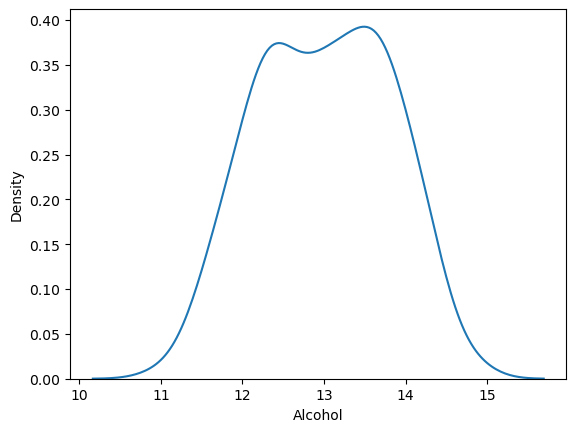

In [21]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

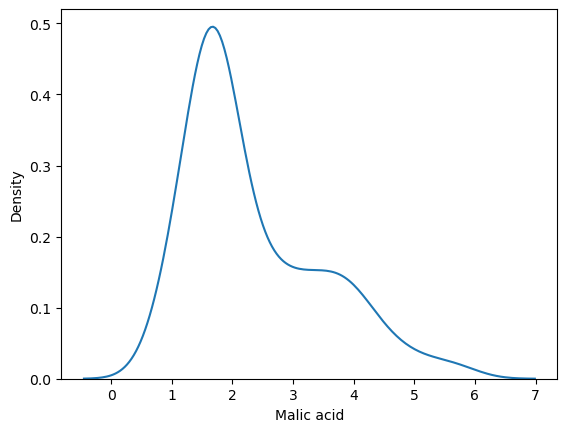

In [22]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

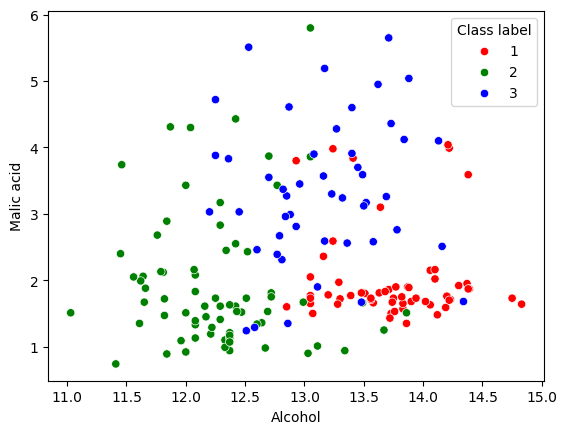

In [23]:
color_dict={1:'red',3:'blue',2:'green'}
sns.scatterplot(x='Alcohol',y='Malic acid',data=df,hue='Class label',palette=color_dict)

In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('Class label',axis=1),df['Class label'],test_size=0.2,random_state=0)
x_train.shape,x_test.shape


((142, 2), (36, 2))

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

scaler.fit(x_train)
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [26]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


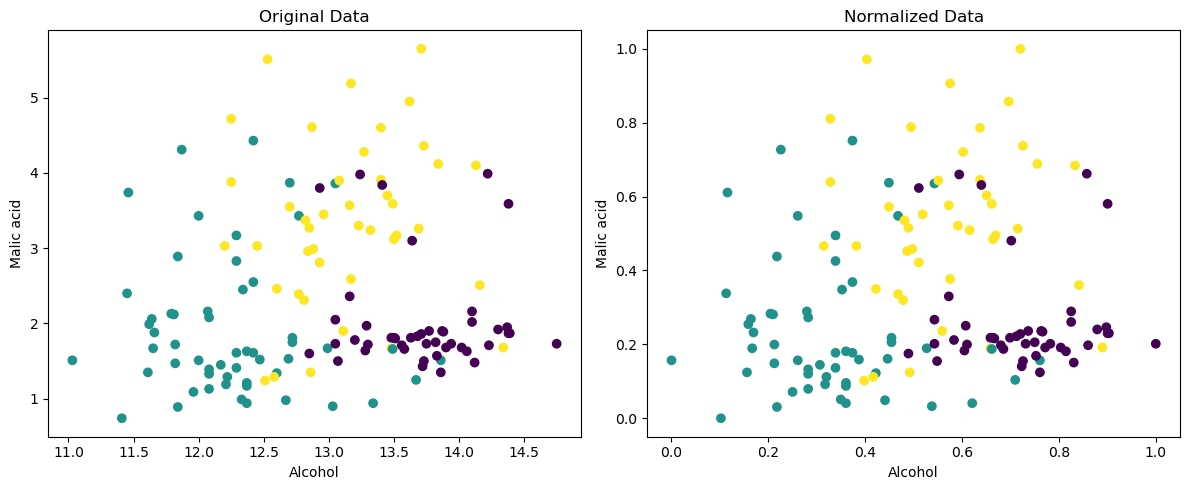

In [27]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(x_train['Alcohol'], x_train['Malic acid'], c=y_train, cmap='viridis')
ax1.set_title('Original Data')
ax1.set_xlabel('Alcohol')
ax1.set_ylabel('Malic acid')
ax2.scatter(x_train_scaled['Alcohol'], x_train_scaled['Malic acid'], c=y_train, cmap='viridis')
ax2.set_title('Normalized Data')
ax2.set_xlabel('Alcohol')
ax2.set_ylabel('Malic acid')
plt.tight_layout()  
plt.show()


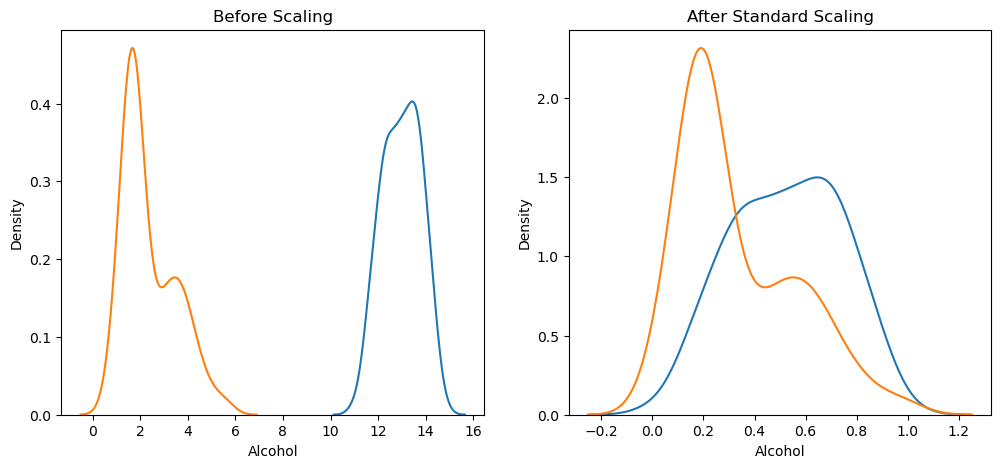

In [30]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Alcohol'], ax=ax1)
sns.kdeplot(x_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(x_train_scaled['Malic acid'], ax=ax2)
plt.show()